# HR Analytics: Employee Attrition Prediction (Advanced)
**Goal:** Understand why employees resign, predict who is likely to leave, and estimate the business value of retention.

**Business questions**
1. Which departments, roles and salary bands lose the most people?
2. Do overtime, pay, promotion gap and distance from home really relate to attrition (statistically)?
3. Which model best identifies leavers (recall matters more than accuracy here)?
4. What drives each employee's risk (SHAP)?
5. How much money can targeted retention save?

**Dataset:** IBM HR Analytics Employee Attrition (1,470 employees, 35 columns). Note: this is a fictional practice dataset created by IBM data scientists.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, classification_report)
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid"); RS = 42
os.makedirs("charts", exist_ok=True)

## 1. Load and clean data

In [2]:
csv_path = next(p for p in ["HR-Employee-Attrition.csv", "../data/HR-Employee-Attrition.csv", "data/HR-Employee-Attrition.csv"] if os.path.exists(p))
df = pd.read_csv(csv_path, encoding="utf-8-sig")
print("Shape:", df.shape, "| Missing values:", df.isnull().sum().sum(), "| Duplicates:", df.duplicated().sum())

# Columns with a single value or just an ID carry no information
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns dropped:", const_cols)
df = df.drop(columns=const_cols + ["EmployeeNumber"])
df["AttritionFlag"] = (df["Attrition"] == "Yes").astype(int)
print("Attrition rate: %.1f%%" % (df["AttritionFlag"].mean() * 100))

Shape: (1470, 35) | Missing values: 0 | Duplicates: 0
Constant columns dropped: ['EmployeeCount', 'Over18', 'StandardHours']
Attrition rate: 16.1%


**Insight:** Data has no missing values, but only about 16% of employees left, so the data is **imbalanced**. Accuracy alone would be misleading (a model saying 'nobody leaves' gets 84% accuracy). We will focus on Recall, F1 and ROC-AUC.

## 2. Feature engineering

In [3]:
df["IncomeVsLevelAvg"] = df["MonthlyIncome"] / df.groupby("JobLevel")["MonthlyIncome"].transform("mean")
df["PromoGapRatio"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["IncomeBand"] = pd.qcut(df["MonthlyIncome"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])
df["AgeGroup"] = pd.cut(df["Age"], [17, 25, 35, 45, 60], labels=["18-25", "26-35", "36-45", "46-60"])
df["TenureGroup"] = pd.cut(df["YearsAtCompany"], [-1, 2, 5, 10, 50], labels=["0-2", "3-5", "6-10", "10+"])
df[["IncomeVsLevelAvg", "PromoGapRatio", "IncomeBand"]].head()

,IncomeVsLevelAvg,PromoGapRatio,IncomeBand
0,1.089185,0.000000,Mid-High
1,0.932341,0.090909,Mid-High
2,0.749933,0.000000,Low
3,1.043806,0.333333,Low
4,1.244387,0.666667,Mid-Low


`IncomeVsLevelAvg` shows whether a person is paid more or less than peers at the same job level. `PromoGapRatio` shows how long someone has waited for a promotion relative to their tenure.

## 3. Exploratory data analysis

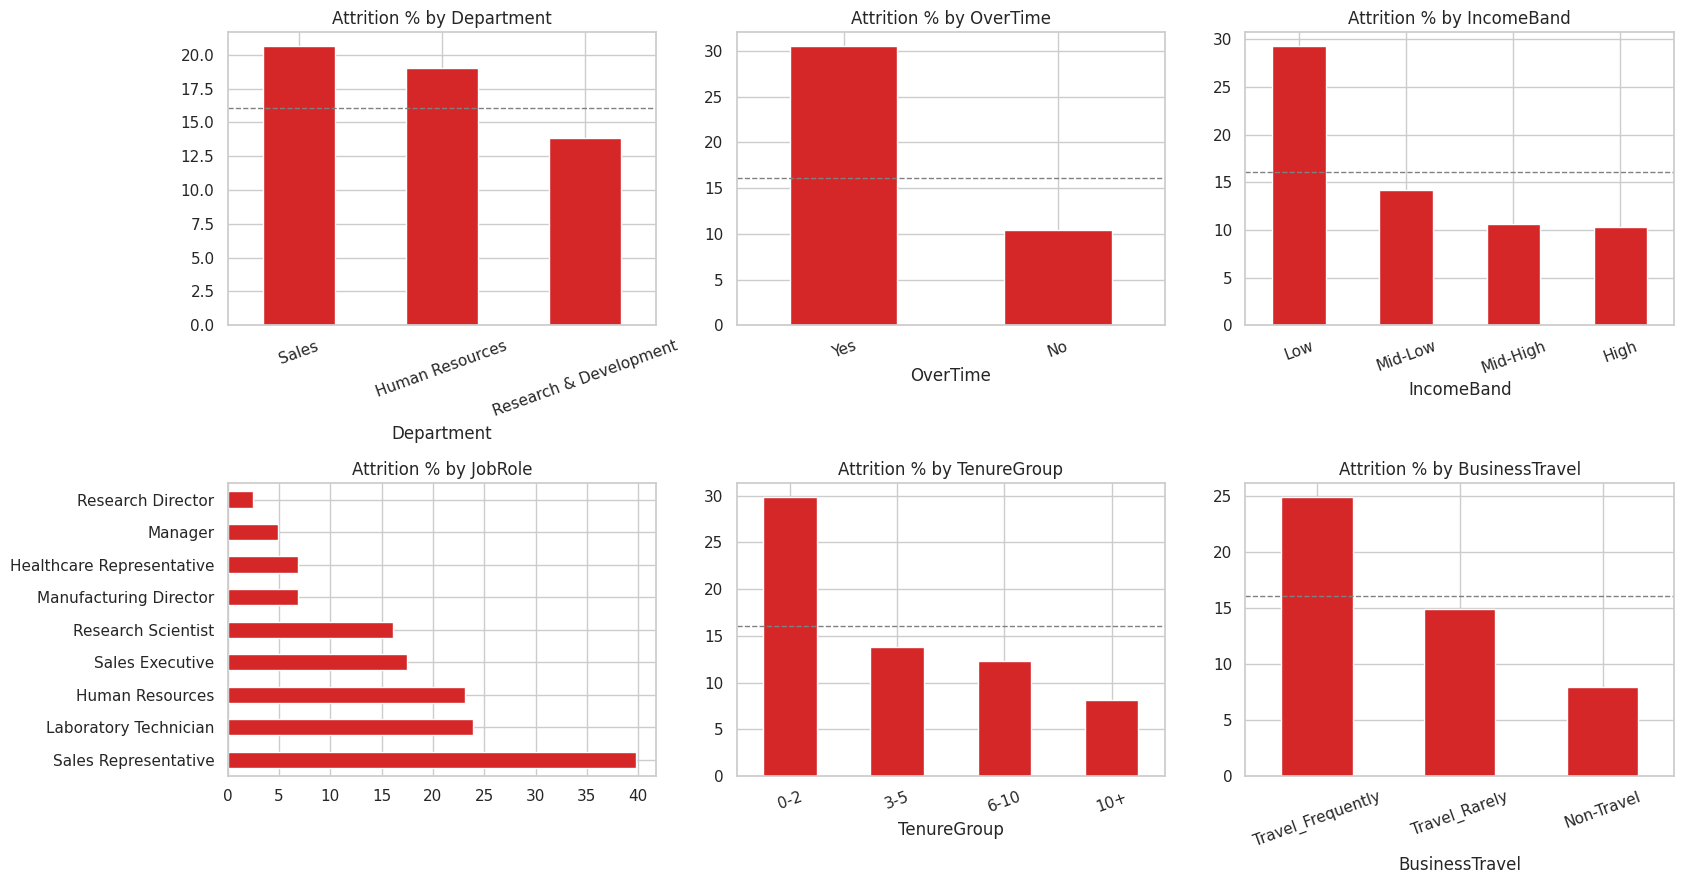

In [4]:
def attr_rate(col):
    return df.groupby(col, observed=True)["AttritionFlag"].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(2, 3, figsize=(17, 9))
for a, col in zip(ax.flat, ["Department", "OverTime", "IncomeBand", "JobRole", "TenureGroup", "BusinessTravel"]):
    r = attr_rate(col)
    if col == "JobRole": r.plot(kind="barh", ax=a, color="#d62728")
    else: r.plot(kind="bar", ax=a, color="#d62728", rot=20)
    a.set_title("Attrition % by " + col); a.set_ylabel(""); a.axhline(16.1, color="grey", ls="--", lw=1)
plt.tight_layout(); plt.savefig("charts/1_eda_attrition_rates.png", dpi=150); plt.show()

In [5]:
for c in ["OverTime", "IncomeBand", "JobRole", "MaritalStatus", "TenureGroup"]:
    print(c, "\n", attr_rate(c).round(1).to_dict(), "\n")

OverTime 
 {'Yes': 30.5, 'No': 10.4} 

IncomeBand 
 {'Low': 29.3, 'Mid-Low': 14.2, 'Mid-High': 10.6, 'High': 10.3} 

JobRole 
 {'Sales Representative': 39.8, 'Laboratory Technician': 23.9, 'Human Resources': 23.1, 'Sales Executive': 17.5, 'Research Scientist': 16.1, 'Manufacturing Director': 6.9, 'Healthcare Representative': 6.9, 'Manager': 4.9, 'Research Director': 2.5} 

MaritalStatus 
 {'Single': 25.5, 'Married': 12.5, 'Divorced': 10.1} 

TenureGroup 
 {'0-2': 29.8, '3-5': 13.8, '6-10': 12.3, '10+': 8.1} 



## 4. Statistical tests (is the pattern real or just chance?)

In [6]:
rows = []
for c in ["OverTime", "Department", "JobRole", "MaritalStatus", "BusinessTravel", "Gender", "EducationField"]:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[c], df["AttritionFlag"]))
    rows.append([c, "Chi-square", round(chi2, 2), p])
for c in ["MonthlyIncome", "Age", "DistanceFromHome", "YearsSinceLastPromotion", "YearsAtCompany", "TotalWorkingYears", "PercentSalaryHike"]:
    t, p = stats.ttest_ind(df.loc[df.AttritionFlag == 1, c], df.loc[df.AttritionFlag == 0, c], equal_var=False)
    rows.append([c, "Welch t-test", round(t, 2), p])
tests = pd.DataFrame(rows, columns=["Feature", "Test", "Statistic", "p_value"])
tests["Significant (p<0.05)"] = np.where(tests["p_value"] < 0.05, "Yes", "No")
tests["p_value"] = tests["p_value"].map(lambda x: f"{x:.4f}")
tests

,Feature,Test,Statistic,p_value,Significant (p<0.05)
0,OverTime,Chi-square,87.56,0.0000,Yes
1,Department,Chi-square,10.80,0.0045,Yes
2,JobRole,Chi-square,86.19,0.0000,Yes
3,MaritalStatus,Chi-square,46.16,0.0000,Yes
4,BusinessTravel,Chi-square,24.18,0.0000,Yes
5,Gender,Chi-square,1.12,0.2906,No
6,EducationField,Chi-square,16.02,0.0068,Yes
7,MonthlyIncome,Welch t-test,-7.48,0.0000,Yes
8,Age,Welch t-test,-5.83,0.0000,Yes
9,DistanceFromHome,Welch t-test,2.89,0.0041,Yes


**Insight:** Features marked *Yes* have a statistically significant relationship with attrition. Remember: **correlation is not causation**. These tests show association, not proof of cause.

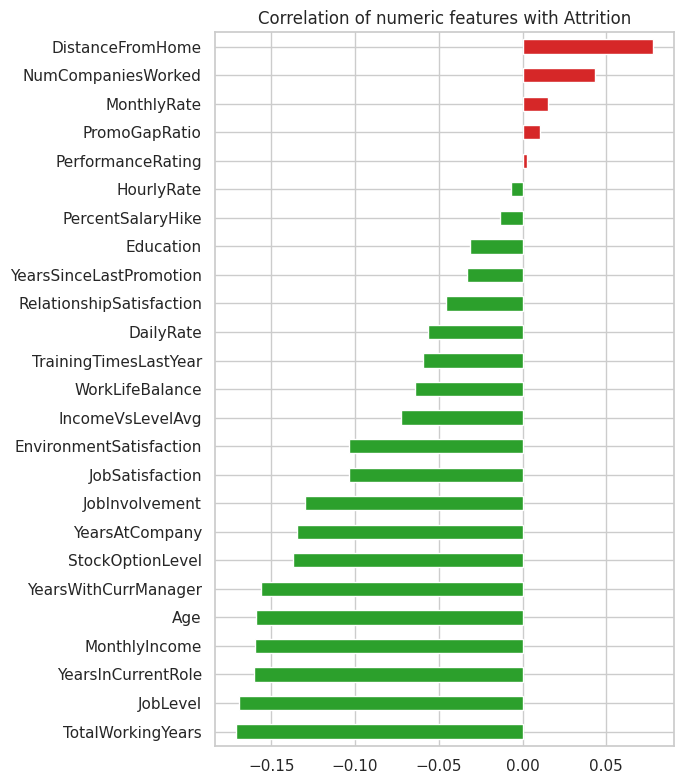

In [7]:
num = df.select_dtypes("number").drop(columns=["AttritionFlag"])
corr = num.corrwith(df["AttritionFlag"]).sort_values()
plt.figure(figsize=(7, 8)); corr.plot(kind="barh", color=["#d62728" if v > 0 else "#2ca02c" for v in corr])
plt.title("Correlation of numeric features with Attrition"); plt.tight_layout()
plt.savefig("charts/2_correlation_with_attrition.png", dpi=150); plt.show()

## 5. Model building
Steps: one-hot encode, **stratified** 80/20 split, handle imbalance with class weights, compare 4 models using **5-fold cross-validation** on the training data, then evaluate once on the untouched test set.

In [8]:
model_df = df.drop(columns=["Attrition", "AgeGroup", "TenureGroup", "IncomeBand"])
X = pd.get_dummies(model_df.drop(columns="AttritionFlag"), drop_first=True).astype(float)
y = model_df["AttritionFlag"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
spw = (ytr == 0).sum() / (ytr == 1).sum()
print("Train:", Xtr.shape, "Test:", Xte.shape, "| scale_pos_weight = %.2f" % spw)

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000, C=0.5)),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=5, min_samples_leaf=20, random_state=RS),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample", min_samples_leaf=3, random_state=RS, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=spw, eval_metric="logloss", random_state=RS),
}
skf = StratifiedKFold(5, shuffle=True, random_state=RS)
res, probs = [], {}
for name, m in models.items():
    cv_auc = cross_val_score(m, Xtr, ytr, cv=skf, scoring="roc_auc").mean()
    m.fit(Xtr, ytr); p = m.predict_proba(Xte)[:, 1]; probs[name] = p; pred = (p >= 0.5).astype(int)
    res.append([name, cv_auc, accuracy_score(yte, pred), precision_score(yte, pred), recall_score(yte, pred),
                f1_score(yte, pred), roc_auc_score(yte, p)])
comp = pd.DataFrame(res, columns=["Model", "CV ROC-AUC", "Accuracy", "Precision", "Recall", "F1", "Test ROC-AUC"]).round(3)
comp = comp.sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
comp.to_csv("model_comparison.csv", index=False); comp

Train: (1176, 46) Test: (294, 46) | scale_pos_weight = 5.19


,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,Test ROC-AUC
0,Logistic Regression,0.831,0.748,0.345,0.638,0.448,0.806
1,XGBoost,0.808,0.806,0.407,0.468,0.436,0.772
2,Random Forest,0.802,0.820,0.312,0.106,0.159,0.778
3,Decision Tree,0.697,0.765,0.347,0.532,0.420,0.723


**Why not just accuracy?** In attrition, missing a real leaver (low recall) is costly. We choose the final model mainly on **cross-validated ROC-AUC** (not on the test set, to avoid peeking), then check recall and F1.

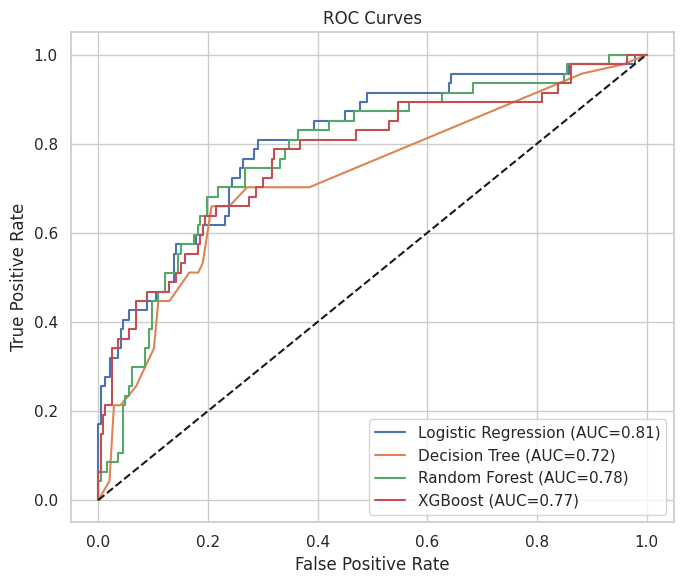

In [9]:
plt.figure(figsize=(7, 6))
for n, p in probs.items():
    f, t, _ = roc_curve(yte, p); plt.plot(f, t, label=f"{n} (AUC={roc_auc_score(yte, p):.2f})")
plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(); plt.tight_layout(); plt.savefig("charts/3_roc_curves.png", dpi=150); plt.show()

## 6. Final model and threshold tuning

In [10]:
best_name = comp.loc[0, "Model"]; best = models[best_name]
print("Final model:", best_name)

# Pick the decision threshold using out-of-fold predictions on TRAIN data only (no test leakage).
# Rule: maximise F2 (recall counts 2x more than precision) because missing a real leaver costs more than a false alarm.
oof = cross_val_predict(best, Xtr, ytr, cv=skf, method="predict_proba")[:, 1]
grid = np.arange(0.2, 0.9, 0.02)
f1s = [fbeta_score(ytr, (oof >= t).astype(int), beta=2) for t in grid]
thr = float(grid[int(np.argmax(f1s))]); print("Chosen threshold: %.2f (default was 0.50)" % thr)

p_te = probs[best_name]; pred_te = (p_te >= thr).astype(int)
final = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Value": [accuracy_score(yte, pred_te), precision_score(yte, pred_te), recall_score(yte, pred_te),
              f1_score(yte, pred_te), roc_auc_score(yte, p_te)]}).round(3)
print(final.to_string(index=False)); print("\n", classification_report(yte, pred_te, target_names=["Stayed", "Left"]))

Final model: Logistic Regression
Chosen threshold: 0.46 (default was 0.50)
   Metric  Value
 Accuracy  0.748
Precision  0.358
   Recall  0.723
       F1  0.479
  ROC-AUC  0.806

               precision    recall  f1-score   support

      Stayed       0.93      0.75      0.83       247
        Left       0.36      0.72      0.48        47

    accuracy                           0.75       294
   macro avg       0.65      0.74      0.66       294
weighted avg       0.84      0.75      0.78       294



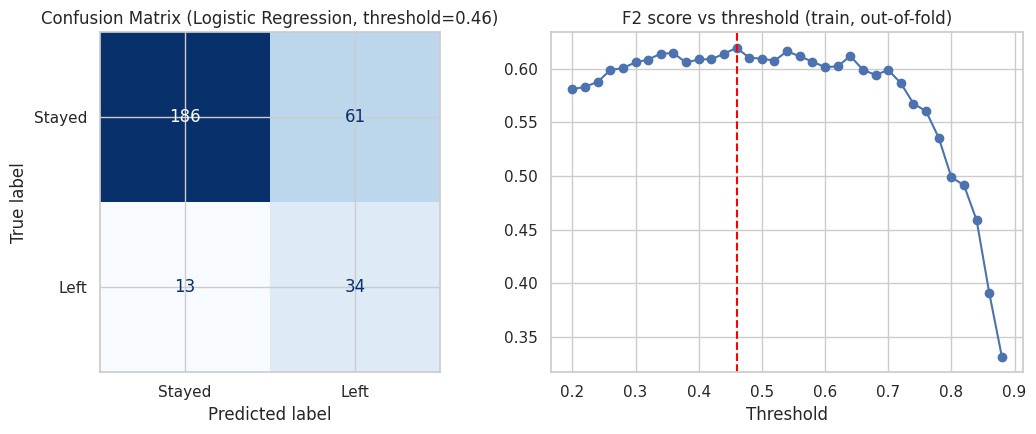

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(yte, pred_te), display_labels=["Stayed", "Left"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title(f"Confusion Matrix ({best_name}, threshold={thr:.2f})")
ax[1].plot(grid, f1s, marker="o"); ax[1].axvline(thr, color="red", ls="--"); ax[1].set_title("F2 score vs threshold (train, out-of-fold)")
ax[1].set_xlabel("Threshold"); plt.tight_layout(); plt.savefig("charts/4_confusion_matrix.png", dpi=150); plt.show()

## 7. Explainability with SHAP (why does the model flag someone?)

SHAP explains: XGBoost


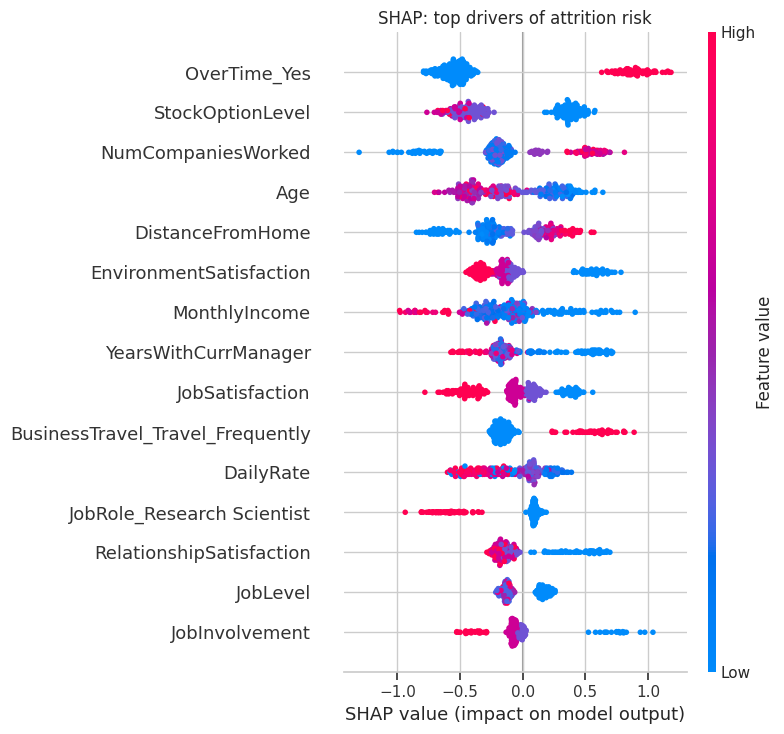

OverTime_Yes                        0.637
StockOptionLevel                    0.421
NumCompaniesWorked                  0.343
Age                                 0.309
DistanceFromHome                    0.296
EnvironmentSatisfaction             0.281
MonthlyIncome                       0.272
YearsWithCurrManager                0.264
JobSatisfaction                     0.246
BusinessTravel_Travel_Frequently    0.237
dtype: float32

In [12]:
# SHAP works on tree models. If the best model is not tree-based, explain XGBoost as the reference tree model.
shap_name = best_name if best_name in ["Random Forest", "XGBoost", "Decision Tree"] else "XGBoost"
sm = models[shap_name]; print("SHAP explains:", shap_name)
expl = shap.TreeExplainer(sm); sv = expl.shap_values(Xte)
if isinstance(sv, list): sv = sv[1]
elif getattr(sv, "ndim", 2) == 3: sv = sv[:, :, 1]
shap.summary_plot(sv, Xte, show=False, max_display=15); plt.title("SHAP: top drivers of attrition risk")
plt.tight_layout(); plt.savefig("charts/5_shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()
imp = pd.Series(np.abs(sv).mean(0), index=Xte.columns).sort_values(ascending=False)
imp.head(15).round(3).rename("mean |SHAP|").to_csv("shap_top_features.csv"); imp.head(10).round(3)

**How to read the plot:** each dot is one employee. Right side = pushes risk **up**, left = pushes risk **down**. Red = high feature value, blue = low. For example, if red dots of `OverTime_Yes` sit on the right, overtime increases attrition risk.

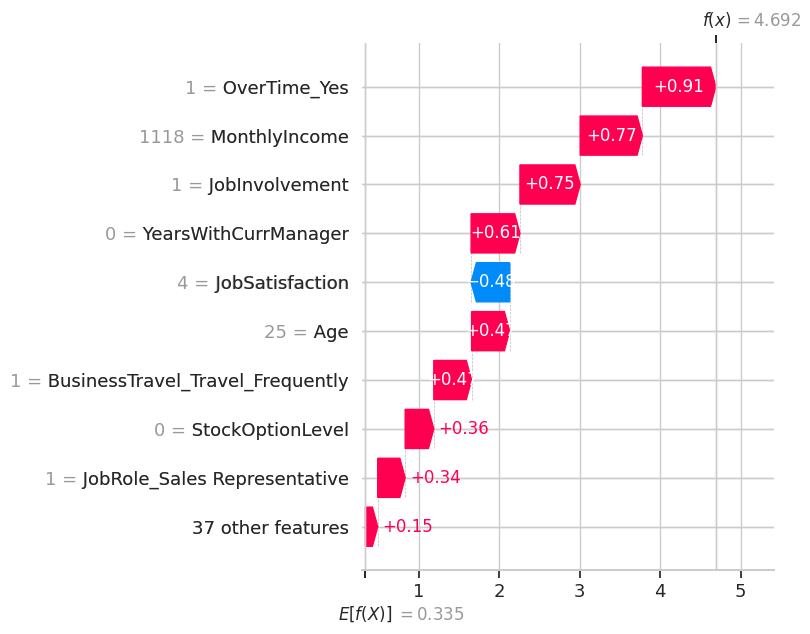

In [13]:
# Individual explanation: highest-risk employee in the test set
i = int(np.argmax(sv.sum(1)))
exp = shap.Explanation(sv[i], base_values=expl.expected_value if np.isscalar(expl.expected_value) else np.ravel(expl.expected_value)[-1],
                       data=Xte.iloc[i], feature_names=Xte.columns)
shap.plots.waterfall(exp, max_display=10, show=False); plt.tight_layout()
plt.savefig("charts/6_shap_individual.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Employee risk scoring (for Power BI)
Every employee gets a risk score from a model that never saw that employee (cross-validated), then a Low / Medium / High bucket.

In [14]:
# Out-of-fold scores for ALL employees (class weights make these a RISK SCORE, not a true probability): every score comes from a model that did not see that employee.
full_cv = StratifiedKFold(5, shuffle=True, random_state=RS)
risk = cross_val_predict(best, X, y, cv=full_cv, method="predict_proba")[:, 1]
out = df.copy()
out["RiskScore"] = risk.round(3)
out["RiskBucket"] = pd.cut(risk, [-0.01, 0.25, 0.5, 1.0], labels=["Low", "Medium", "High"])
out["ReplacementCost"] = (out["MonthlyIncome"] * 12 * 0.5).round(0)   # assumption: 50% of annual salary
out.insert(0, "EmployeeID", range(1, len(out) + 1))
out.to_csv("hr_clean_for_powerbi.csv", index=False)
print(out["RiskBucket"].value_counts().to_string())
print("\nActual attrition % per bucket (sanity check):")
print(out.groupby("RiskBucket", observed=True)["AttritionFlag"].mean().mul(100).round(1).to_string())

RiskBucket
Low       694
High      454
Medium    322

Actual attrition % per bucket (sanity check):
RiskBucket
Low        4.2
Medium    11.5
High      37.7


## 9. Business impact (assumptions are stated clearly)

In [15]:
leavers = out[out.AttritionFlag == 1]
hi_leavers = leavers[leavers.RiskBucket == "High"]
RETENTION_SUCCESS = 0.30     # assumption: HR actions retain 30% of the high-risk people who would have left
print(f"Total leavers: {len(leavers)} | Estimated replacement cost: ${leavers['ReplacementCost'].sum():,.0f}")
print(f"Leavers who were in the High-risk bucket: {len(hi_leavers)} ({len(hi_leavers)/len(leavers):.0%} of all leavers)")
print(f"High-risk group size: {(out.RiskBucket=='High').sum()} employees ({(out.RiskBucket=='High').mean():.0%} of workforce)")
print(f"Replacement cost of those leavers: ${hi_leavers['ReplacementCost'].sum():,.0f}")
print(f"If targeted retention saves {RETENTION_SUCCESS:.0%} of them: about ${hi_leavers['ReplacementCost'].sum()*RETENTION_SUCCESS:,.0f} saved")

Total leavers: 237 | Estimated replacement cost: $6,807,246
Leavers who were in the High-risk bucket: 171 (72% of all leavers)
High-risk group size: 454 employees (31% of workforce)
Replacement cost of those leavers: $4,149,366
If targeted retention saves 30% of them: about $1,244,810 saved


Replacement cost is assumed to be 50% of annual salary (a common HR rule of thumb) and the 30% retention success rate is also an assumption. Change both in the code to test other scenarios.

## 10. Key findings and recommendations
**What the data says (see EDA, tests and SHAP):**
- Employees working **overtime** leave at about 30% vs 10% for others, and overtime is the #1 SHAP driver.
- **Low income band** employees leave at about 29% vs about 10% in the top bands; **Sales Representatives** have the highest role attrition (about 40%).
- **First 2 years** are the riskiest (about 30% attrition); **single** employees, frequent travellers, low stock-option levels and long commutes also add risk.
- Gender, last salary hike % and years since last promotion are **not** significantly related to attrition here.

**Recommendations**
1. Review workload and overtime policy, especially for Sales and Lab Technician roles.
2. Check pay for the lowest income band and for people paid below their job-level average (`IncomeVsLevelAvg` below 1).
3. Strengthen onboarding and mentoring in the first 2 years.
4. Run stay-interviews for the High-risk list (`hr_clean_for_powerbi.csv`) and re-score monthly.

**Limitations:** fictional practice dataset; associations are not proof of causation; the model catches only part of the leavers, so scores should support (not replace) manager judgement.